# Sniff dataset — chapter 2

Look at any canonical JSONL and immediately understand what's in it. **No training, no models** — just stats and plots.

**Input**
- A canonical JSONL produced by chapter 1 (e.g. `data/processed_jsonl/rog_dialog_instance.jsonl`).

**Output**
- Cell-by-cell console output (the notebook *is* the report when you're developing).
- One consolidated markdown report at `data/reports/<jsonl_stem>_report.md`.
- A handful of PNGs alongside it: per-split label bar charts, duration histograms, duration boxplot.

**What we look at**
1. Record counts per split.
2. Per-split label-key coverage (which records have which labels).
3. Per-label, per-split class distribution + imbalance warnings.
4. Audio durations from disk (we open each WAV's header — that doubles as a splitter sanity-check).
5. Speaker counts and the top-N most-frequent `file_id`s per split.
6. Missing-value report on the optional schema fields.
7. **Frame-level** records (chapter 4 territory) are handled gracefully: token-level label distributions and per-instance sequence-length stats.

**Convention.** Notebook-first. Every function lives in a cell here; once chapter 2 has a couple of stable notebooks we'll factor shared logic into `utils_analysis.py`.

---

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Find PROJECT_ROOT via utils_dataprep (chapter 1 already does this nicely).
HERE = Path.cwd()
if HERE.name != "2_data_analysis":
    candidate = HERE / "2_data_analysis"
    if candidate.exists():
        HERE = candidate
# We need utils_dataprep from chapter 1.
chapter1 = HERE.parent / "1_data_prep"
sys.path.insert(0, str(chapter1))

import utils_dataprep as udp

PROJECT_ROOT = udp.PROJECT_ROOT
print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Chapter dir = {HERE}")

PROJECT_ROOT = /home/ivan/Posao_IJS/Stepping_Stones/github_full_repo/slavic-speech-pipeline
Chapter dir = /home/ivan/Posao_IJS/Stepping_Stones/github_full_repo/slavic-speech-pipeline/2_data_analysis


Standard third-party imports. `matplotlib` isn't in chapter-1's `requirements.txt`; for chapter 2 onwards you'll want to uncomment it (or `pip install matplotlib`).

In [2]:
import json
import wave
from collections import Counter, defaultdict
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

# Quiet plot style — readable on a dark or light background.
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True
plt.rcParams["grid.alpha"] = 0.3

---

## 1. Config

All knobs live here. Edit, re-run the cells below.

**Conventions**
- `jsonl_path` is project-relative.
- `output_dir` is where the markdown report + PNGs go. Test mode mirrors this to `data/test_reports/`.
- `imbalance_max_ratio` — if max-class / min-class > this in any split, log a loud warning.
- `imbalance_rare_pct` — warn on any class that's below this percentage of its split.
- `top_n_files` — how many top `file_id`s to show per split.
- `duration_hist_bins` — bin count for duration histograms.

In [3]:
@dataclass
class Config:
    # Input
    # jsonl_path: str = "data/processed_jsonl/rog_dialog_instance.jsonl"
    jsonl_path: str = "data/processed_jsonl/rog_instance.jsonl"

    # Output
    output_dir: str = "data/reports"

    # Imbalance warning thresholds
    imbalance_max_ratio: float = 20.0   # ratio of biggest class to smallest
    imbalance_rare_pct: float  = 1.0    # any class under this % triggers warn

    # Display knobs
    top_n_files: int = 5
    duration_hist_bins: int = 40

    # Test mode (samples the first test_n records, writes to data/test_reports/)
    test_mode: bool = False
    test_n: int = 50


cfg = Config()
print(cfg)
if cfg.test_mode:
    udp.banner("🧪 TEST MODE ENABLED", char="-")

Config(jsonl_path='data/processed_jsonl/rog_instance.jsonl', output_dir='data/reports', imbalance_max_ratio=20.0, imbalance_rare_pct=1.0, top_n_files=5, duration_hist_bins=40, test_mode=False, test_n=50)


---

## 2. Load and validate

The input must already be canonical-schema-clean (chapter 1's job). We re-validate defensively — if anything looks wrong, we want to know before plotting.

In [4]:
records = udp.read_jsonl(cfg.jsonl_path)
n_total, n_valid, errs = udp.validate_jsonl(records)
print(f"Loaded {n_total} records, {n_valid} valid.")
if errs:
    print("First errors:")
    for e in errs[:5]:
        print(f"   {e}")
    raise ValueError("input JSONL failed canonical-schema validation")

if cfg.test_mode:
    records = records[: cfg.test_n]
    print(f"🧪 capped to {len(records)} records")

# Resolve output dir (test mode → data/test_reports/)
out_dir_str = (cfg.output_dir
               if not cfg.test_mode
               else cfg.output_dir.replace("data/reports", "data/test_reports"))
out_dir = udp.from_project_relative(out_dir_str)
out_dir.mkdir(parents=True, exist_ok=True)

# Stem used for all output filenames
jsonl_stem = Path(cfg.jsonl_path).stem  # "rog_dialog_instance"
print(f"Output dir = {out_dir}")
print(f"Stem       = {jsonl_stem}")

Loaded 37022 records, 37022 valid.
Output dir = /home/ivan/Posao_IJS/Stepping_Stones/github_full_repo/slavic-speech-pipeline/data/reports
Stem       = rog_instance


---

## 3. Record counts per split

The first thing you want to see when you load a new dataset. Numbers here should match what chapter 1 reported.

In [5]:
SPLITS = ["train", "dev", "test"]

split_counts = Counter(r["split"] for r in records)
print(f"{'split':<8} {'count':>8} {'pct':>8}")
print("-" * 28)
for s in SPLITS:
    n = split_counts.get(s, 0)
    pct = 100 * n / max(1, len(records))
    print(f"{s:<8} {n:>8} {pct:>7.1f}%")
print("-" * 28)
print(f"{'total':<8} {len(records):>8}")

split       count      pct
----------------------------
train       30471    82.3%
dev          4297    11.6%
test         2254     6.1%
----------------------------
total       37022


---

## 4. Instance-level vs frame-level records

A record is *frame-level* if any of its label values is a list (chapter 4 territory). The rest of the notebook handles both paths — instance-level stats apply to instance records, frame-level stats apply to frame records, and the two are reported separately.

In [6]:
def is_frame_record(r: dict) -> bool:
    return any(isinstance(v, list) for v in r.get("labels", {}).values())

instance_records = [r for r in records if not is_frame_record(r)]
frame_records    = [r for r in records if is_frame_record(r)]

print(f"Instance-level: {len(instance_records)}")
print(f"Frame-level:    {len(frame_records)}")

Instance-level: 37022
Frame-level:    0


---

## 5. Label coverage per split

Which label keys exist, and on how many records per split. This is where you spot "oh, only the Dialog subcorpus has sentiment" without grep-ing through 500 EXB files.

In [7]:
def label_keys_per_split(records: list[dict]) -> dict[str, Counter]:
    """For each split, return {label_key: count_of_records_with_that_key}."""
    out: dict[str, Counter] = {s: Counter() for s in SPLITS}
    for r in records:
        s = r["split"]
        for k in r.get("labels", {}).keys():
            out[s][k] += 1
    return out

coverage = label_keys_per_split(records)
all_keys = sorted({k for c in coverage.values() for k in c})

if not all_keys:
    print("⚠️  no label keys found across any record")
else:
    header = f"{'label_key':<30}" + "".join(f"{s:>10}" for s in SPLITS) + f"{'total':>10}"
    print(header)
    print("-" * len(header))
    for k in all_keys:
        row = f"{k:<30}"
        total = 0
        for s in SPLITS:
            n = coverage[s][k]
            total += n
            row += f"{n:>10}"
        row += f"{total:>10}"
        print(row)

label_key                          train       dev      test     total
----------------------------------------------------------------------
disfluency_count                   30471      4297      2254     37022
filled_pause_present               30471      4297      2254     37022


---

## 6. Pick which scalar label keys to plot

We auto-plot every scalar (non-list) label key present in the instance records. Frame-level (list) labels get their own section below.

In [8]:
def scalar_label_keys(records: list[dict]) -> list[str]:
    """Return sorted label keys whose values are scalars (str/int/float), not lists."""
    keys: set[str] = set()
    for r in records:
        for k, v in r.get("labels", {}).items():
            if not isinstance(v, list):
                keys.add(k)
    return sorted(keys)

scalar_keys = scalar_label_keys(instance_records)
print(f"Scalar label keys to plot: {scalar_keys}")

Scalar label keys to plot: ['disfluency_count', 'filled_pause_present']


---

## 7. Per-label class distribution + imbalance warnings

For each scalar label, print a per-split count table and save a per-split bar chart. Imbalance warnings fire when:
- max-class / min-class ratio > `imbalance_max_ratio`, or
- any class falls below `imbalance_rare_pct` of its split.


----------------------------------------------------------------------
label: disfluency_count
----------------------------------------------------------------------
class                              train       dev      test     total
----------------------------------------------------------------------
0                                  27965      3779      1894     33638
1                                   2413       493       350      3256
2                                     90        25        10       125
3                                      3         0         0         3
  ⚠️  max/min ratio = 11212.7× (threshold 20×)
  ⚠️  rare class '2': 125 (0.34%)
  ⚠️  rare class '3': 3 (0.01%)


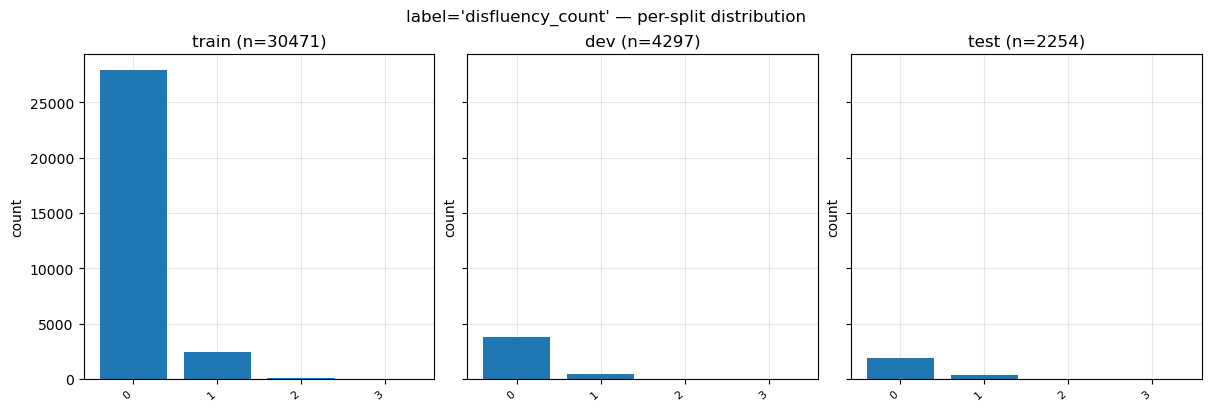

  saved data/reports/rog_instance_label_disfluency_count.png

----------------------------------------------------------------------
label: filled_pause_present
----------------------------------------------------------------------
class                              train       dev      test     total
----------------------------------------------------------------------
0                                  27965      3779      1894     33638
1                                   2506       518       360      3384


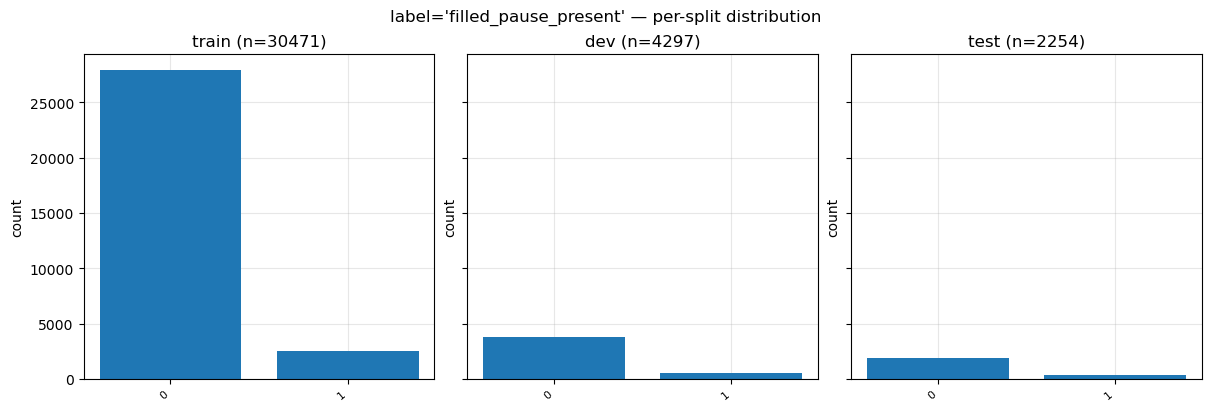

  saved data/reports/rog_instance_label_filled_pause_present.png


In [9]:
def label_value_counts(records: list[dict], key: str) -> dict[str, Counter]:
    out: dict[str, Counter] = {s: Counter() for s in SPLITS}
    for r in records:
        v = r.get("labels", {}).get(key)
        if v is None:
            continue
        out[r["split"]][v] += 1
    return out


def imbalance_warnings(counts: Counter, *, max_ratio: float, rare_pct: float) -> list[str]:
    if not counts:
        return []
    total = sum(counts.values())
    warns: list[str] = []
    sorted_items = counts.most_common()
    biggest = sorted_items[0][1]
    smallest = sorted_items[-1][1]
    if smallest > 0 and biggest / smallest > max_ratio:
        warns.append(f"max/min ratio = {biggest/smallest:.1f}× (threshold {max_ratio:.0f}×)")
    for label, n in counts.items():
        pct = 100 * n / total
        if pct < rare_pct:
            warns.append(f"rare class '{label}': {n} ({pct:.2f}%)")
    return warns


def plot_label_distribution(counts_by_split: dict[str, Counter], key: str, out_path: Path):
    # All seen classes, sorted by total frequency descending
    totals: Counter = Counter()
    for c in counts_by_split.values():
        totals.update(c)
    classes = [c for c, _ in totals.most_common()]
    if not classes:
        return None

    fig, axes = plt.subplots(1, len(SPLITS), figsize=(4 * len(SPLITS), 4),
                             sharey=True, constrained_layout=True)
    if len(SPLITS) == 1:
        axes = [axes]
    fig.suptitle(f"label='{key}' — per-split distribution", fontsize=12)
    for ax, s in zip(axes, SPLITS):
        c = counts_by_split.get(s, Counter())
        vals = [c.get(cls, 0) for cls in classes]
        ax.bar(range(len(classes)), vals)
        ax.set_xticks(range(len(classes)))
        ax.set_xticklabels(classes, rotation=40, ha="right", fontsize=8)
        ax.set_title(f"{s} (n={sum(vals)})")
        ax.set_ylabel("count")
    fig.savefig(out_path)
    plt.show()
    plt.close(fig)
    return out_path


# Run it for every scalar label key
label_plot_paths: dict[str, Path] = {}
label_warnings: dict[str, list[str]] = {}

for key in scalar_keys:
    udp.banner(f"label: {key}", char="-")
    counts_by_split = label_value_counts(instance_records, key)

    # Print table
    classes = sorted({c for c in counts_by_split.values() for c in c})  # noqa
    classes = sorted({c for sp in counts_by_split.values() for c in sp})
    header = f"{'class':<30}" + "".join(f"{s:>10}" for s in SPLITS) + f"{'total':>10}"
    print(header)
    print("-" * len(header))
    for cls in classes:
        row = f"{cls:<30}"
        tot = 0
        for s in SPLITS:
            n = counts_by_split[s].get(cls, 0)
            tot += n
            row += f"{n:>10}"
        row += f"{tot:>10}"
        print(row)

    # Warnings (computed on the *total* counts, not per-split)
    total_counts: Counter = Counter()
    for sp in counts_by_split.values():
        total_counts.update(sp)
    warns = imbalance_warnings(total_counts,
                               max_ratio=cfg.imbalance_max_ratio,
                               rare_pct=cfg.imbalance_rare_pct)
    label_warnings[key] = warns
    for w in warns:
        print(f"  ⚠️  {w}")

    # Plot
    png = out_dir / f"{jsonl_stem}_label_{key}.png"
    label_plot_paths[key] = plot_label_distribution(counts_by_split, key, png)
    print(f"  saved {png.relative_to(PROJECT_ROOT)}")

---

## 8. Audio durations (from disk)

We open every cut WAV's header to get its true on-disk duration. This is a free splitter-sanity-check — if the JSONL says `end_t - start_t = 1.500s` but the WAV has 0.500 s of audio, that's a real bug we want to know about.

For ~hundreds of records, this is fast. For ~tens of thousands, it's still fine — header reads are cheap.

In [10]:
def wav_duration(path: Path) -> float | None:
    try:
        with wave.open(str(path), "rb") as w:
            return w.getnframes() / float(w.getframerate())
    except Exception:
        return None


def collect_durations(records: list[dict]) -> tuple[dict[str, np.ndarray], list[dict]]:
    """
    Returns:
      durations_by_split: {split: np.ndarray of durations in seconds}
      mismatches: records whose disk duration disagrees with end_t-start_t by >50 ms
    """
    out: dict[str, list[float]] = {s: [] for s in SPLITS}
    mismatches: list[dict] = []
    for r in tqdm(records, desc="WAV headers", unit="rec"):
        p = udp.from_project_relative(r["audio_path"])
        d = wav_duration(p)
        if d is None:
            continue
        out.setdefault(r["split"], []).append(d)
        if "start_t" in r and "end_t" in r:
            expected = r["end_t"] - r["start_t"]
            if abs(d - expected) > 0.050:
                mismatches.append({"instance_id": r["instance_id"],
                                   "expected_s": expected, "actual_s": d})
    return ({s: np.array(v, dtype=float) for s, v in out.items()}, mismatches)


durations, mismatches = collect_durations(records)
for s in SPLITS:
    d = durations.get(s, np.array([]))
    if d.size == 0:
        print(f"{s:<6}: (no audio readable)")
        continue
    print(f"{s:<6}: n={d.size:>5}  "
          f"min={d.min():.2f}s  p50={np.percentile(d, 50):.2f}s  "
          f"p90={np.percentile(d, 90):.2f}s  p99={np.percentile(d, 99):.2f}s  "
          f"max={d.max():.2f}s")

if mismatches:
    print(f"\n⚠️  {len(mismatches)} records have on-disk duration off by >50 ms from JSONL:")
    for m in mismatches[:5]:
        print(f"    {m['instance_id']}: expected {m['expected_s']:.3f}s, actual {m['actual_s']:.3f}s")
    if len(mismatches) > 5:
        print(f"    ... and {len(mismatches) - 5} more")
else:
    print("\n✅ no duration mismatches between JSONL and on-disk WAVs")

WAV headers:   0%|          | 0/37022 [00:00<?, ?rec/s]

train : n=30471  min=0.00s  p50=0.36s  p90=0.74s  p99=1.12s  max=1690.87s
dev   : n= 4297  min=0.05s  p50=0.37s  p90=0.78s  p99=1.31s  max=839.32s
test  : n= 2254  min=0.06s  p50=0.35s  p90=0.71s  p99=1.20s  max=1708.82s

✅ no duration mismatches between JSONL and on-disk WAVs


---

## 9. Duration plots

A histogram per split (use it to pick `max_length` for the trainer) and a boxplot for shape comparison.

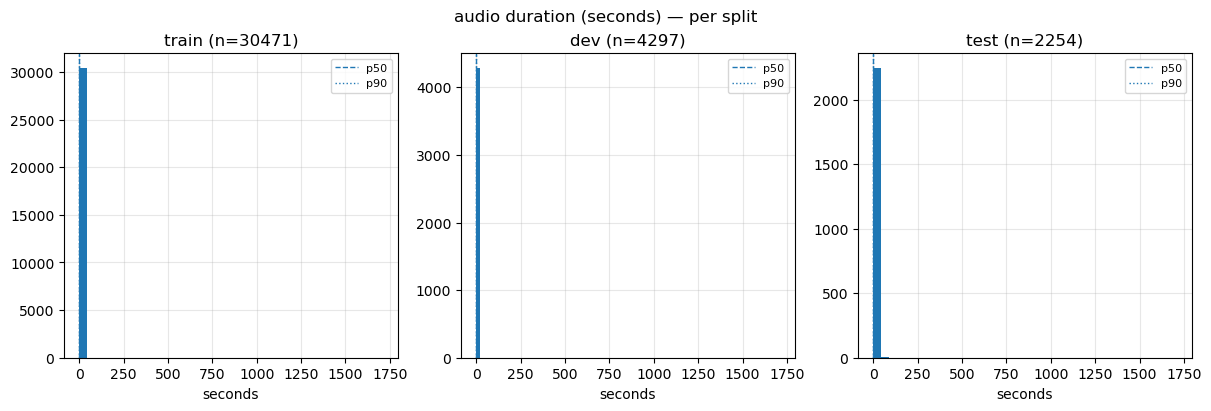

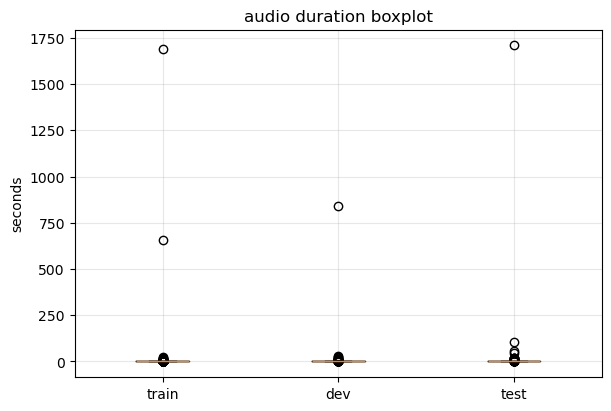

saved data/reports/rog_instance_duration_hist.png
saved data/reports/rog_instance_duration_box.png


In [11]:
def plot_duration_hist(durations: dict[str, np.ndarray], out_path: Path, bins: int):
    fig, axes = plt.subplots(1, len(SPLITS), figsize=(4 * len(SPLITS), 4),
                             sharex=True, sharey=False, constrained_layout=True)
    fig.suptitle("audio duration (seconds) — per split", fontsize=12)
    if len(SPLITS) == 1:
        axes = [axes]
    for ax, s in zip(axes, SPLITS):
        d = durations.get(s, np.array([]))
        if d.size == 0:
            ax.set_title(f"{s} (empty)")
            continue
        ax.hist(d, bins=bins)
        ax.axvline(np.percentile(d, 50), linestyle="--", linewidth=1, label="p50")
        ax.axvline(np.percentile(d, 90), linestyle=":",  linewidth=1, label="p90")
        ax.set_title(f"{s} (n={d.size})")
        ax.set_xlabel("seconds")
        ax.legend(fontsize=8)
    fig.savefig(out_path)
    plt.show()
    plt.close(fig)
    return out_path


def plot_duration_box(durations: dict[str, np.ndarray], out_path: Path):
    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    data = [durations.get(s, np.array([])) for s in SPLITS]
    data = [d for d in data if d.size > 0]
    labels_used = [s for s in SPLITS if durations.get(s, np.array([])).size > 0]
    ax.boxplot(data, tick_labels=labels_used, showfliers=True)
    ax.set_ylabel("seconds")
    ax.set_title("audio duration boxplot")
    fig.savefig(out_path)
    plt.show()
    plt.close(fig)
    return out_path


hist_png = plot_duration_hist(durations, out_dir / f"{jsonl_stem}_duration_hist.png",
                              bins=cfg.duration_hist_bins)
box_png  = plot_duration_box(durations, out_dir / f"{jsonl_stem}_duration_box.png")
print(f"saved {hist_png.relative_to(PROJECT_ROOT)}")
print(f"saved {box_png.relative_to(PROJECT_ROOT)}")

---

## 10. Speakers and top `file_id`s per split

Speaker leakage between splits is a model-killer for speech tasks. This is your visual check.

Note: chapter 1's split assigner is already group-aware (groups by `file_id`), but if `file_id` doesn't map cleanly to a single speaker (multi-speaker recordings), some speaker overlap across splits is *expected*. Look at this section to confirm the level you're seeing is what you expect.

In [12]:
def speakers_per_split(records: list[dict]) -> dict[str, set]:
    out: dict[str, set] = {s: set() for s in SPLITS}
    for r in records:
        if "speaker" in r:
            out.setdefault(r["split"], set()).add(r["speaker"])
    return out


speakers = speakers_per_split(records)
print("Speaker counts per split:")
for s in SPLITS:
    print(f"  {s:<6}: {len(speakers[s])} unique speakers")

# Cross-split overlap (only an issue if your prep notebook splits *within* a file)
print("\nSpeaker overlap between splits:")
for i, a in enumerate(SPLITS):
    for b in SPLITS[i+1:]:
        overlap = speakers[a] & speakers[b]
        print(f"  {a} ∩ {b}: {len(overlap)} speakers")

# Top file_ids per split (sanity: are some recordings dominating?)
print(f"\nTop {cfg.top_n_files} file_ids per split (by record count):")
for s in SPLITS:
    fcounts = Counter(r["file_id"] for r in records if r["split"] == s and "file_id" in r)
    top = fcounts.most_common(cfg.top_n_files)
    print(f"  {s}:")
    for fid, n in top:
        print(f"    {fid:<40} {n:>6}")

Speaker counts per split:
  train : 56 unique speakers
  dev   : 11 unique speakers
  test  : 6 unique speakers

Speaker overlap between splits:
  train ∩ dev: 1 speakers
  train ∩ test: 0 speakers
  dev ∩ test: 0 speakers

Top 5 file_ids per split (by record count):
  train:
    Rog-Art-J-Gvecg-P580023                     913
    Rog-Art-J-Gvecg-P500026                     808
    Rog-Art-J-Gvecg-P580003                     807
    Rog-Art-J-Gvecg-P580002                     800
    Rog-Art-J-Gvecg-P580047                     797
  dev:
    Rog-Art-J-Gvecg-P580009                     800
    Rog-Art-J-Gvecg-P500054                     778
    Rog-Art-J-Gvecg-P500048                     759
    Rog-Art-N-G6116-P611601                     700
    Rog-Art-N-G6007-P600702                     471
  test:
    Rog-Art-J-Gvecg-P500028                     790
    Rog-Art-N-G6103-P610302                     674
    Rog-Art-N-G5035-P600034                     496
    Rog-Art-N-G5019-P600012     

---

## 11. Missing-value report

Optional canonical-schema fields: `file_id`, `start_t`, `end_t`, `speaker`, `text`, `frame_rate_hz`. Plus we check `metadata.source_file` since chapter 1's splitter relies on it.

In [13]:
def missing_value_report(records: list[dict]) -> dict[str, int]:
    optional = ["file_id", "start_t", "end_t", "speaker", "text", "frame_rate_hz"]
    missing: dict[str, int] = {k: 0 for k in optional}
    missing["metadata.source_file"] = 0
    for r in records:
        for k in optional:
            if k not in r:
                missing[k] += 1
        if not r.get("metadata", {}).get("source_file"):
            missing["metadata.source_file"] += 1
    return missing


missing = missing_value_report(records)
print(f"{'field':<24} {'missing':>10} {'pct':>10}")
print("-" * 46)
for k, n in missing.items():
    pct = 100 * n / max(1, len(records))
    print(f"{k:<24} {n:>10} {pct:>9.1f}%")

field                       missing        pct
----------------------------------------------
file_id                           0       0.0%
start_t                           0       0.0%
end_t                             0       0.0%
speaker                           0       0.0%
text                              0       0.0%
frame_rate_hz                 37022     100.0%
metadata.source_file              0       0.0%


---

## 12. Frame-level records (chapter 4 territory)

If the JSONL has frame-level entries (any label value is a list), we report:
- Token-level distribution of each frame label (how many 0s, 1s, … across all frames).
- Per-instance sequence-length stats so you know how the frame counts shape up.

If there are no frame records, this section just prints a friendly skip message.

In [14]:
def frame_label_keys(records: list[dict]) -> list[str]:
    keys: set[str] = set()
    for r in records:
        for k, v in r.get("labels", {}).items():
            if isinstance(v, list):
                keys.add(k)
    return sorted(keys)


if not frame_records:
    print("(no frame-level records in this JSONL — skipping)")
else:
    fkeys = frame_label_keys(frame_records)
    print(f"Frame label keys: {fkeys}\n")

    # Per-split sequence-length stats
    print(f"{'split':<6} {'n':>5} {'p50_len':>10} {'p90_len':>10} {'min_len':>10} {'max_len':>10}")
    print("-" * 56)
    for s in SPLITS:
        lens = []
        for r in frame_records:
            if r["split"] != s:
                continue
            for v in r.get("labels", {}).values():
                if isinstance(v, list):
                    lens.append(len(v))
                    break
        if not lens:
            print(f"{s:<6} {'-':>5} {'-':>10} {'-':>10} {'-':>10} {'-':>10}")
            continue
        a = np.array(lens)
        print(f"{s:<6} {a.size:>5} {np.percentile(a,50):>10.1f} {np.percentile(a,90):>10.1f} "
              f"{a.min():>10} {a.max():>10}")

    # Token-level class distribution per frame label
    print()
    for k in fkeys:
        udp.banner(f"frame label: {k}", char="-")
        tok_counts: dict[str, Counter] = {s: Counter() for s in SPLITS}
        for r in frame_records:
            seq = r.get("labels", {}).get(k)
            if not isinstance(seq, list):
                continue
            tok_counts[r["split"]].update(seq)
        # Print
        classes = sorted({c for c in tok_counts.values() for c in c})  # noqa
        classes = sorted({c for sp in tok_counts.values() for c in sp})
        header = f"{'class':<10}" + "".join(f"{s:>10}" for s in SPLITS) + f"{'total':>10}"
        print(header)
        print("-" * len(header))
        for cls in classes:
            row = f"{str(cls):<10}"
            tot = 0
            for s in SPLITS:
                n = tok_counts[s].get(cls, 0)
                tot += n
                row += f"{n:>10}"
            row += f"{tot:>10}"
            print(row)

(no frame-level records in this JSONL — skipping)


---

## 13. Write the consolidated markdown report

Everything we just printed, condensed into one `.md` file alongside the PNGs. Open it in any markdown viewer — it's the single artifact you can hand to a collaborator or commit alongside experiment notes.

In [15]:
def write_markdown_report(
    cfg: Config,
    out_dir: Path,
    jsonl_stem: str,
    records: list[dict],
    instance_records: list[dict],
    frame_records: list[dict],
    durations: dict[str, np.ndarray],
    mismatches: list[dict],
    coverage: dict[str, Counter],
    scalar_keys: list[str],
    label_warnings: dict[str, list[str]],
    label_plot_paths: dict[str, Path],
    hist_png: Path,
    box_png: Path,
    speakers: dict[str, set],
    missing: dict[str, int],
) -> Path:
    md_path = out_dir / f"{jsonl_stem}_report.md"
    L: list[str] = []
    L.append(f"# Sniff report — `{cfg.jsonl_path}`")
    L.append("")
    L.append(f"- **Total records:** {len(records)}")
    L.append(f"- **Instance-level:** {len(instance_records)}")
    L.append(f"- **Frame-level:** {len(frame_records)}")
    L.append("")

    # Split table
    L.append("## Splits")
    L.append("")
    L.append("| split | count | pct |")
    L.append("|---|---:|---:|")
    for s in SPLITS:
        n = sum(1 for r in records if r["split"] == s)
        L.append(f"| {s} | {n} | {100*n/max(1,len(records)):.1f}% |")
    L.append("")

    # Label coverage
    L.append("## Label coverage")
    L.append("")
    all_keys = sorted({k for c in coverage.values() for k in c})
    if all_keys:
        L.append("| label_key | " + " | ".join(SPLITS) + " | total |")
        L.append("|---|" + "|".join(["---:"] * (len(SPLITS) + 1)) + "|")
        for k in all_keys:
            cells_row = []
            tot = 0
            for s in SPLITS:
                n = coverage[s][k]
                tot += n
                cells_row.append(str(n))
            L.append(f"| {k} | " + " | ".join(cells_row) + f" | {tot} |")
        L.append("")

    # Per-label sections
    for k in scalar_keys:
        L.append(f"## Label `{k}`")
        L.append("")
        L.append(f"![label_{k}]({jsonl_stem}_label_{k}.png)")
        L.append("")
        ws = label_warnings.get(k, [])
        if ws:
            L.append("**Warnings**")
            for w in ws:
                L.append(f"- ⚠️ {w}")
            L.append("")

    # Durations
    L.append("## Audio durations (from disk)")
    L.append("")
    L.append("| split | n | min | p50 | p90 | p99 | max |")
    L.append("|---|---:|---:|---:|---:|---:|---:|")
    for s in SPLITS:
        d = durations.get(s, np.array([]))
        if d.size == 0:
            L.append(f"| {s} | 0 | - | - | - | - | - |")
            continue
        L.append(f"| {s} | {d.size} | {d.min():.2f} | {np.percentile(d,50):.2f} | "
                 f"{np.percentile(d,90):.2f} | {np.percentile(d,99):.2f} | {d.max():.2f} |")
    L.append("")
    L.append(f"![duration_hist]({hist_png.name})")
    L.append("")
    L.append(f"![duration_box]({box_png.name})")
    L.append("")
    if mismatches:
        L.append(f"**⚠️ {len(mismatches)} records have on-disk duration off by >50 ms from JSONL.**")
        L.append("")

    # Speakers
    L.append("## Speakers")
    L.append("")
    L.append("| split | unique speakers |")
    L.append("|---|---:|")
    for s in SPLITS:
        L.append(f"| {s} | {len(speakers[s])} |")
    L.append("")

    # Missing
    L.append("## Missing optional fields")
    L.append("")
    L.append("| field | missing | pct |")
    L.append("|---|---:|---:|")
    for k, n in missing.items():
        pct = 100 * n / max(1, len(records))
        L.append(f"| {k} | {n} | {pct:.1f}% |")
    L.append("")

    md_path.write_text("\n".join(L), encoding="utf-8")
    return md_path


md_path = write_markdown_report(
    cfg, out_dir, jsonl_stem,
    records, instance_records, frame_records,
    durations, mismatches,
    coverage, scalar_keys, label_warnings, label_plot_paths,
    hist_png, box_png,
    speakers, missing,
)
print(f"✅ wrote {md_path.relative_to(PROJECT_ROOT)}")

✅ wrote data/reports/rog_instance_report.md


---

## 14. What's next

You've now seen what's in the JSONL. If everything looks reasonable — split sizes balanced enough, no horrifying class imbalance, durations within a sane range, no duration mismatches — you're cleared to head to **`3_instance_models/train_instance.ipynb`** and start training.

If something looks broken, the fix lives in chapter 1, not here. Common patterns:
- Bad class balance → check the prep notebook's filtering / fallback rules.
- Duration mismatches → re-run the audio splitter with `force=True`.
- Missing labels → check which subcorpus you pulled (e.g. ROG sentiment lives only in `ROG-Dialog`, not `ROG-Art`).